In [1]:
import numpy as np
import xarray as xr
import json
import os

import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit

from feature_retreiver import (
    FeatureRetreiver, compute_bl_rh18
)

In [2]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(latitude * np.pi / 180)

In [3]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [4]:
def calculate_rolling_average(
        case: str,
        dataset: xr.DataArray,
        variable: str,
        case_dict: dict,
        dt: int = 600
) -> np.ndarray:
    data = dataset[variable].sel(case=case).values
    lat = case_dict[case]['lat']
    T = calculate_T(lat)
    window_size = int(2*T/dt)
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

## TEST CASE

In [5]:
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

test_training_set_name = "ePBL_paper_linear_2283_1mOSBL"

In [6]:
test_ds = xr.open_dataset(f"{root_dir}/{test_training_set_name}_training_dataset/case_11/output.nc").isel(lat=0, lon=0)

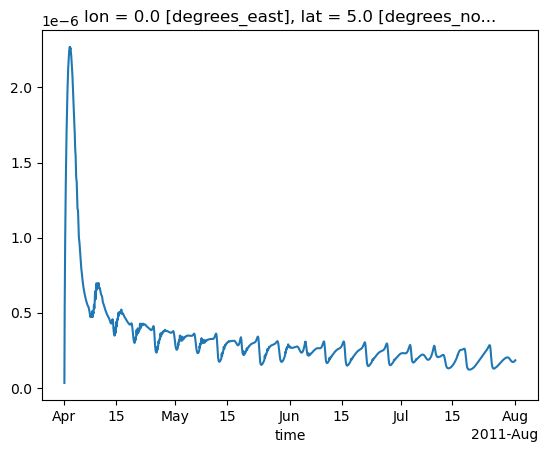

In [9]:
(test_ds['nuh']*test_ds['NN'].where(test_ds['NN'] > 0)).sum(dim="zi").plot()

In [8]:
test_ds['nuh']

<xarray.DataArray 'nuh' (time: 2929, zi: 401)> Size: 5MB
[1174529 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 23kB 2011-04-01 ... 2011-08-01
    lon      float32 4B 0.0
    lat      float32 4B 5.0
    zi       (time, zi) float32 5MB ...
Attributes:
    units:          m2/s
    long_name:      turbulent diffusivity of heat
    standard_name:  ??
    path:           /turbulence
    cell_methods:   time: mean

In [9]:
time, z = test_ds.time.values, test_ds.zi[0].values

In [10]:
G = -test_ds.G.values

/tmp/ipykernel_1210993/3242891393.py:3: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(time, z, G.T, levels=levels, norm=colors.LogNorm(vmin=1e-12, vmax=1e-4), extend="both")


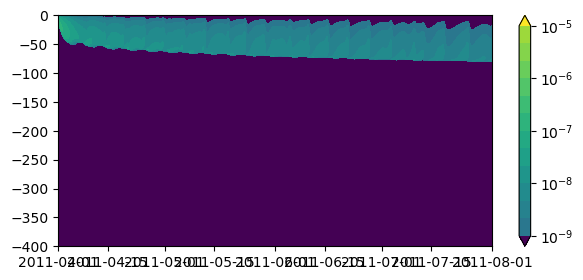

In [9]:
levels = np.logspace(-9, -5, 13)
plt.figure(figsize=(7,3))
plt.contourf(time, z, G.T, levels=levels, norm=colors.LogNorm(vmin=1e-12, vmax=1e-4), extend="both")
cbar = plt.colorbar()
cbar.set_ticks(np.logspace(-9, -5, 5))

In [10]:
NN = test_ds.NN.values

/tmp/ipykernel_1210993/807871155.py:3: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(time, z, NN.T, # levels=levels, norm=colors.LogNorm(vmin=1e-12, vmax=1e-4), extend="both")


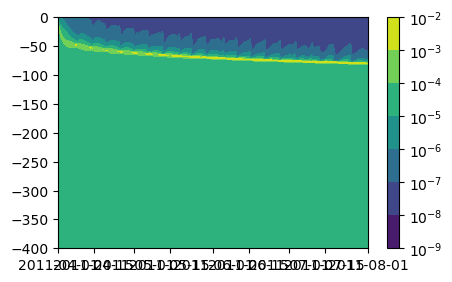

In [11]:
# levels = np.logspace(-12, -5, 15)
plt.figure(figsize=(5,3))
plt.contourf(time, z, NN.T, # levels=levels, norm=colors.LogNorm(vmin=1e-12, vmax=1e-4), extend="both")
             norm=colors.LogNorm())
cbar = plt.colorbar()
# cbar.set_ticks(np.logspace(-12, -5, 8))

## CASE COMPARISON

In [12]:
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

training_set_name_1 = "ePBL_paper_linear_2283_1mOSBL"
training_set_name_2 = "ePBL_paper_linear_2283_32mOSBL"

In [12]:
with open(f"{root_dir}/{training_set_name_1}_training_set_cases.json", "r") as file:
    gotm_case_dict_1 = json.load(file)

with open(f"{root_dir}/{training_set_name_2}_training_set_cases.json", "r") as file:
    gotm_case_dict_2 = json.load(file)

In [55]:
target_specs = {'temp_grad': 0.04, 'tx': 1.0, 'lat': 10.0, 'heat_flux': 0}

for case, specs in gotm_case_dict_1.items():
    if specs == target_specs:
        case_1 = case 
    else: pass

for case, specs in gotm_case_dict_2.items():
    if specs == target_specs:
        case_2 = case
    else: pass

In [56]:
print(case_1, case_2)

case_401 case_401


In [57]:
ds_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_training_dataset/{case_1}/output.nc").isel(lat=0, lon=0)
ds_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_training_dataset/{case_2}/output.nc").isel(lat=0, lon=0)

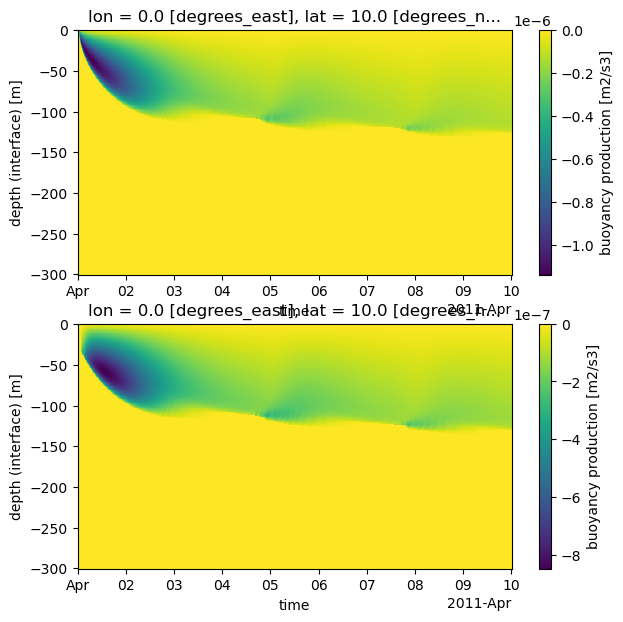

In [58]:
fig, ax = plt.subplots(2,1,figsize=(7,7))

ds_1.G.T.plot(ax=ax[0])
ds_2.G.T.plot(ax=ax[1])

# SINGLE TRAINING SET ANALYSIS

In [18]:
training_set_name = "rotating_vs_non_rotating_strong_stratification"
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

In [19]:
with open(f"{root_dir}/{training_set_name}_training_set_cases.json", "r") as file:
    gotm_case_dict = json.load(file)

In [20]:
feature_retreiver = FeatureRetreiver(
    training_set_dir=os.path.join(root_dir, f"{training_set_name}_training_dataset"),
    case_dict=gotm_case_dict
)

In [21]:
latitudes = np.array([case['lat'] for case in gotm_case_dict.values()])
wind_stresses = np.array([case['tx'] for case in gotm_case_dict.values()])
heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
temp_grads = np.array([case['temp_grad'] for case in gotm_case_dict.values()])

In [22]:
cases = np.arange(1,len(latitudes)+1)

In [23]:
# this takes waaaay too long; need to optimize
# Actually, Qing says that gaea is simply very slow at analysis; we have to move it to PPAN
m_star_dataset = feature_retreiver.make_m_star_dataset()
m_star_dataset.to_netcdf(f"{root_dir}/{training_set_name}_m_star_G.nc")

In [24]:
bl_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=compute_bl_rh18,
    processing_method_name="bl",
    variable="nuh",
    coordinates=["time"]
)

bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_bl.nc")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning

In [25]:
storage_term_dataset = feature_retreiver.make_storage_term_dataset()
buoyancy_mixing_term_dataset = feature_retreiver.make_buoyancy_mixing_term_dataset()

In [14]:
m_star_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_m_star_G.nc")
bl_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_bl.nc")

##### $m_*$ and $H_{bl}$ sel method: rolling average

In [15]:
m_stars = []
bls = []
mlds = []

dt = 1800
last_day_index = int(24 * 60 * 60 / dt)

for i in cases:
    m_star_rolling_avg = calculate_rolling_average(
        case=f"case_{i}",
        dataset=m_star_dataset,
        variable='m_star',
        case_dict=gotm_case_dict,
        dt=dt
    )

    m_stars.append(np.nanmean(m_star_rolling_avg[-last_day_index:-1]))

    bl_rolling_avg = calculate_rolling_average(
        case=f"case_{i}",
        dataset=bl_dataset,
        variable='bl',
        case_dict=gotm_case_dict,
        dt=dt
    )

    bls.append(np.nanmean(bl_rolling_avg[-last_day_index:-1]))


m_stars = np.array(m_stars)
bls = np.array(bls)

/tmp/ipykernel_79073/1635012154.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 2 * np.pi / calculate_f(latitude)


OverflowError: cannot convert float infinity to integer

In [1]:
save = False

for i in range(1,30):
    plt.figure(figsize=(12,3))
    plt.plot(m_star_dataset.time.values, m_star_dataset.m_star.values[i,:], color="black",
             label="$m_*$")
    # plt.plot(m_star_dataset.time.values, m_stars[i]*np.ones(len(m_star_dataset.m_star.values[i,:])), 
    #          color="red", linestyle="dashed", label="mean $m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

NameError: name 'plt' is not defined

In [2]:
save = False

for i in range(1,30):
    plt.figure(figsize=(12,3))
    plt.plot(bl_dataset.time.values, bl_dataset.bl.values[i,:], color="black",
             label="OSBL depth [m]")
    # plt.plot(bl_dataset.time.values, bls[i]*np.ones(len(bl_dataset.bl.values[i,:])), 
    #          color="red", linestyle="dashed", label="mean MLD")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/mld_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}.png", dpi=300)

NameError: name 'plt' is not defined

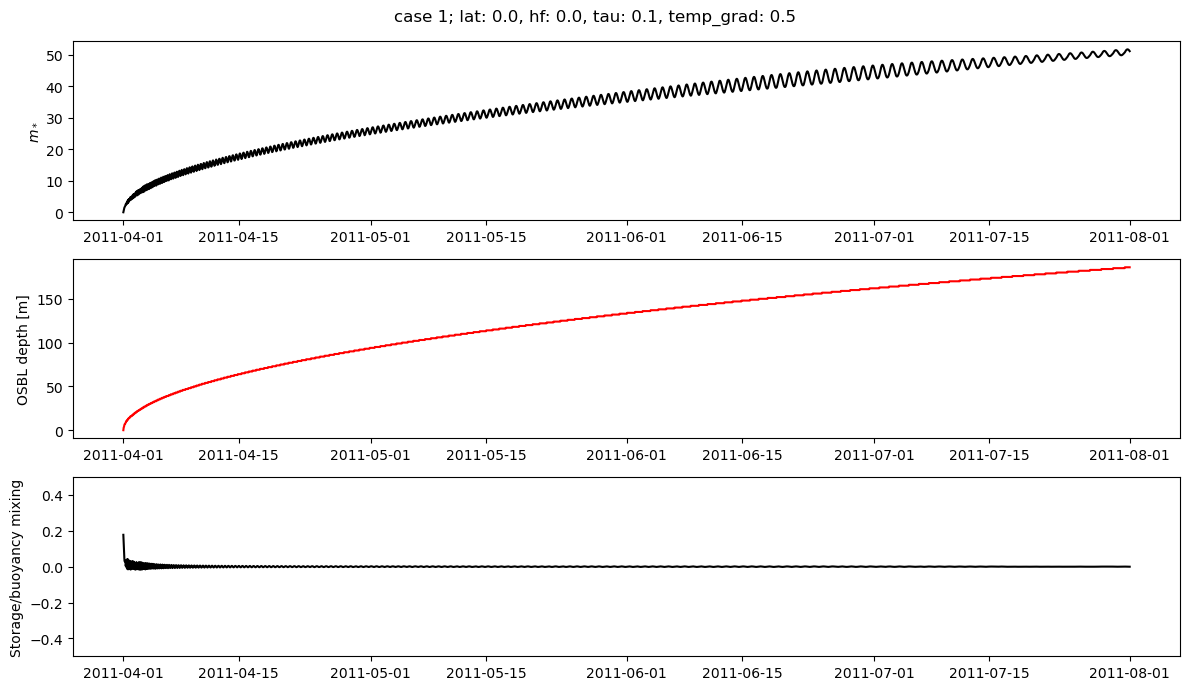

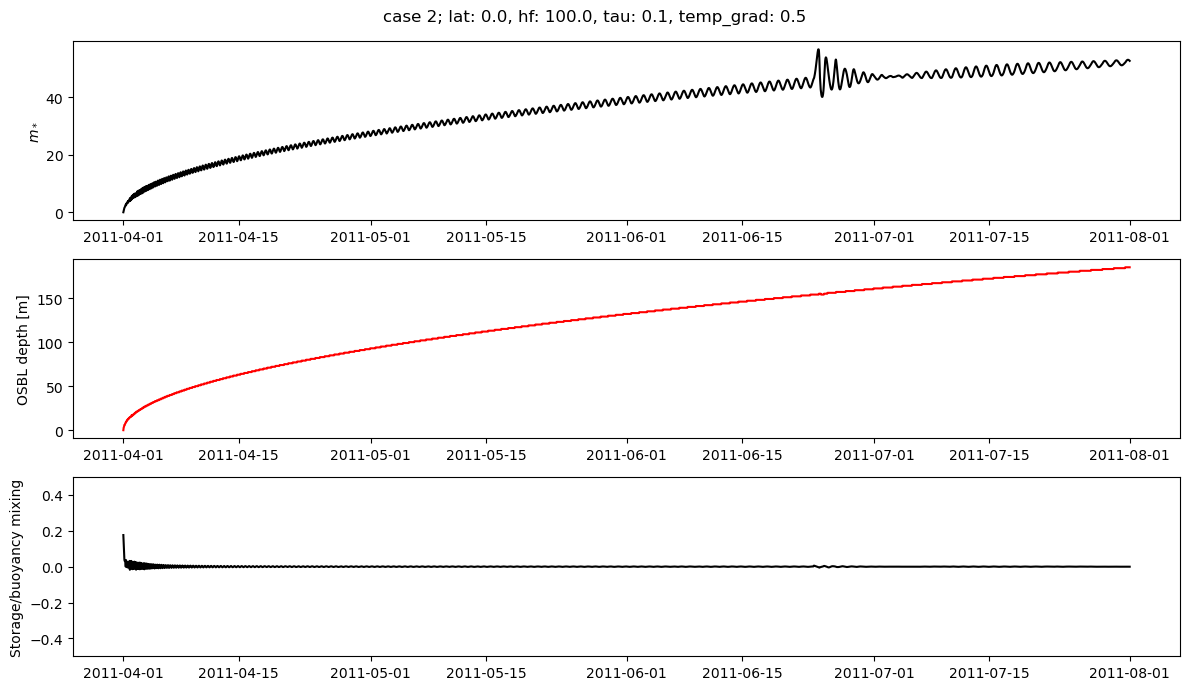

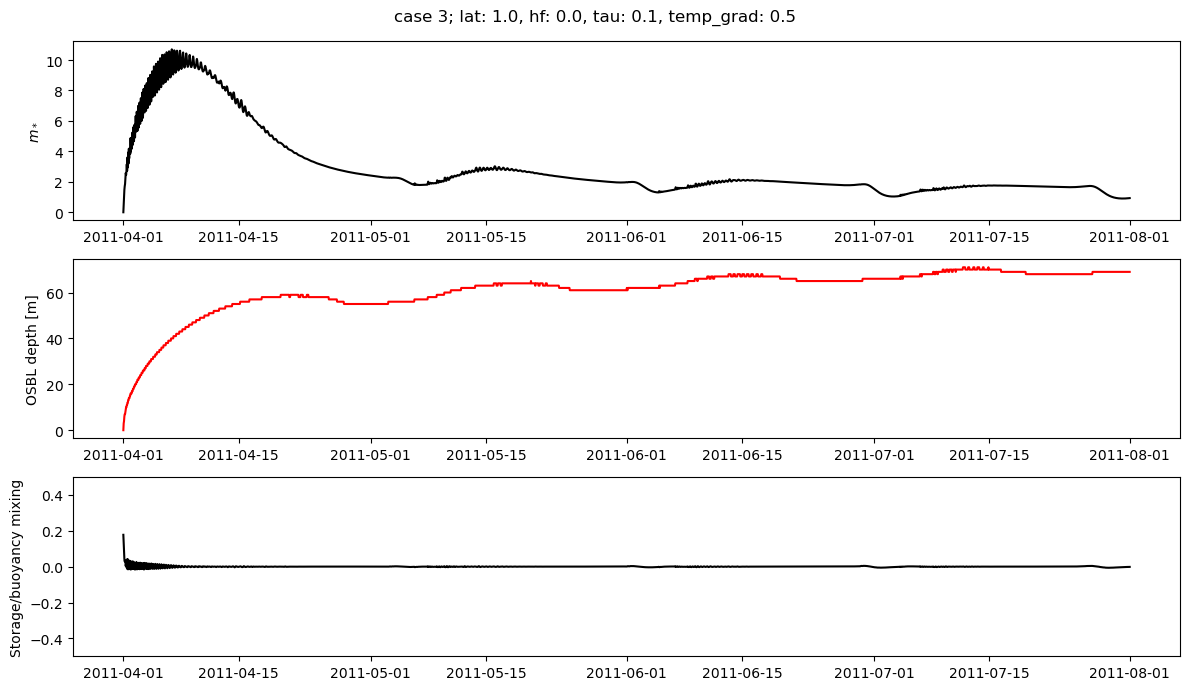

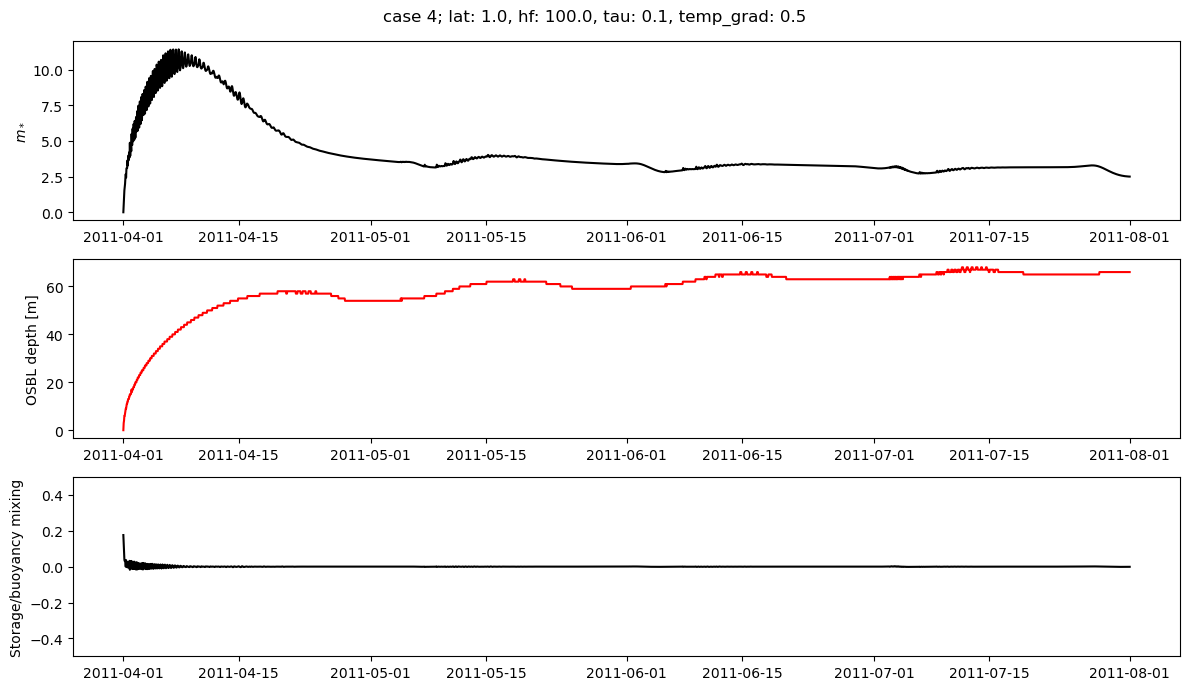

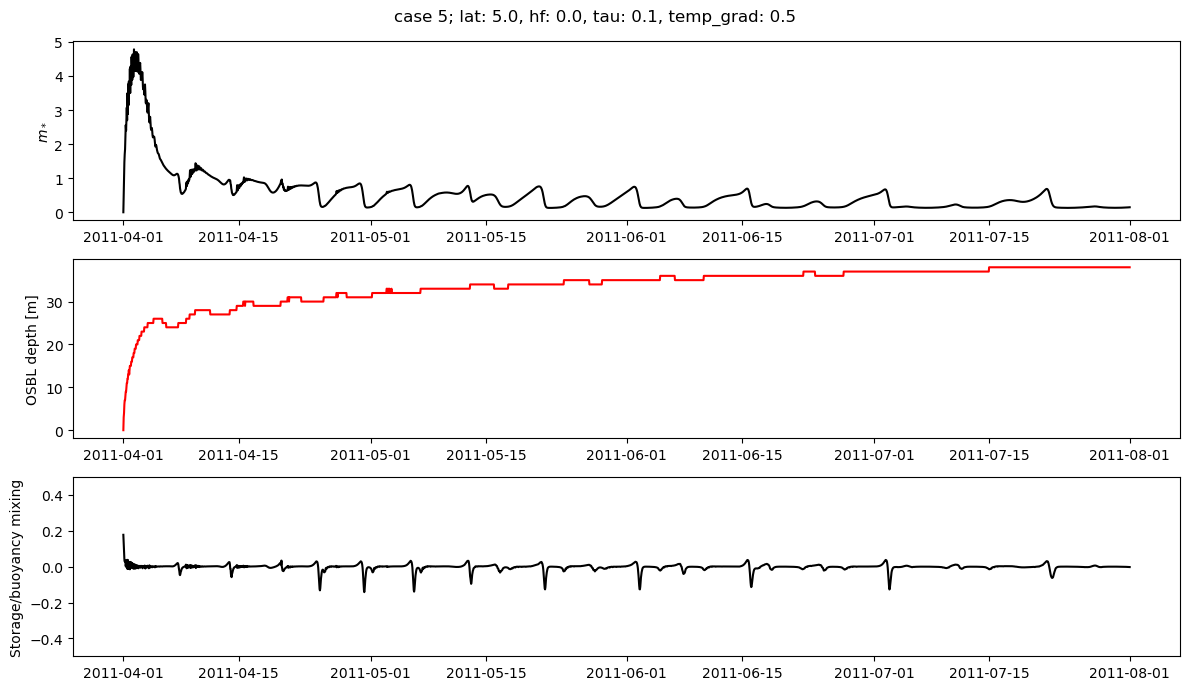

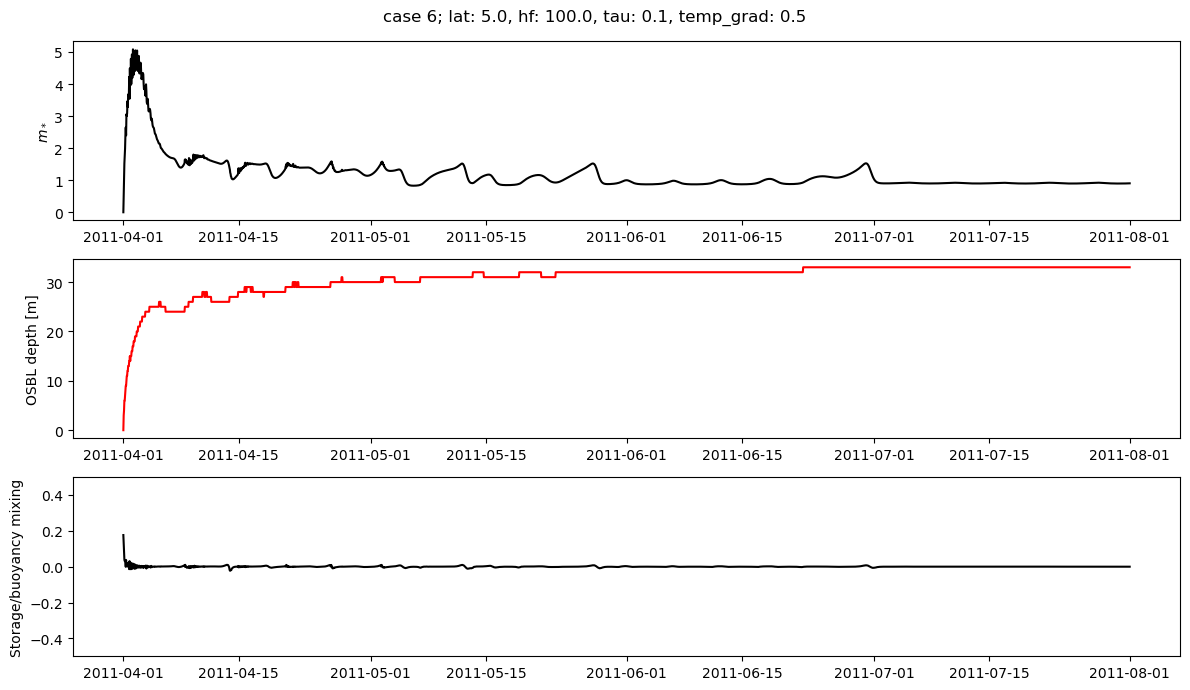

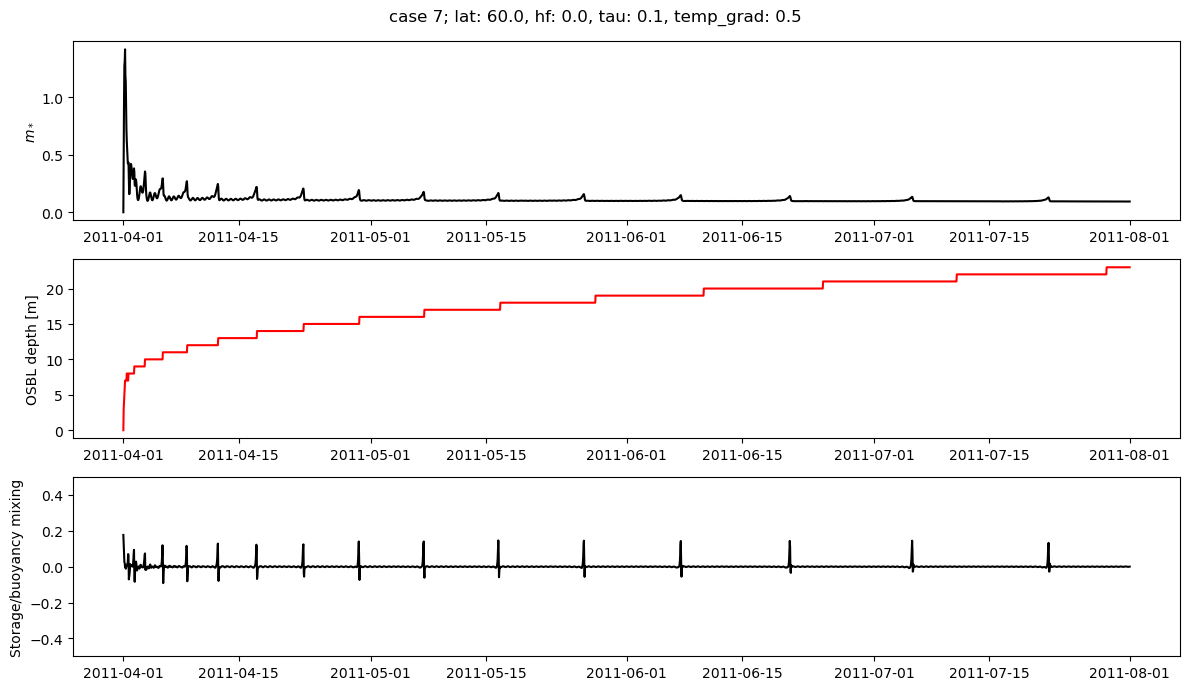

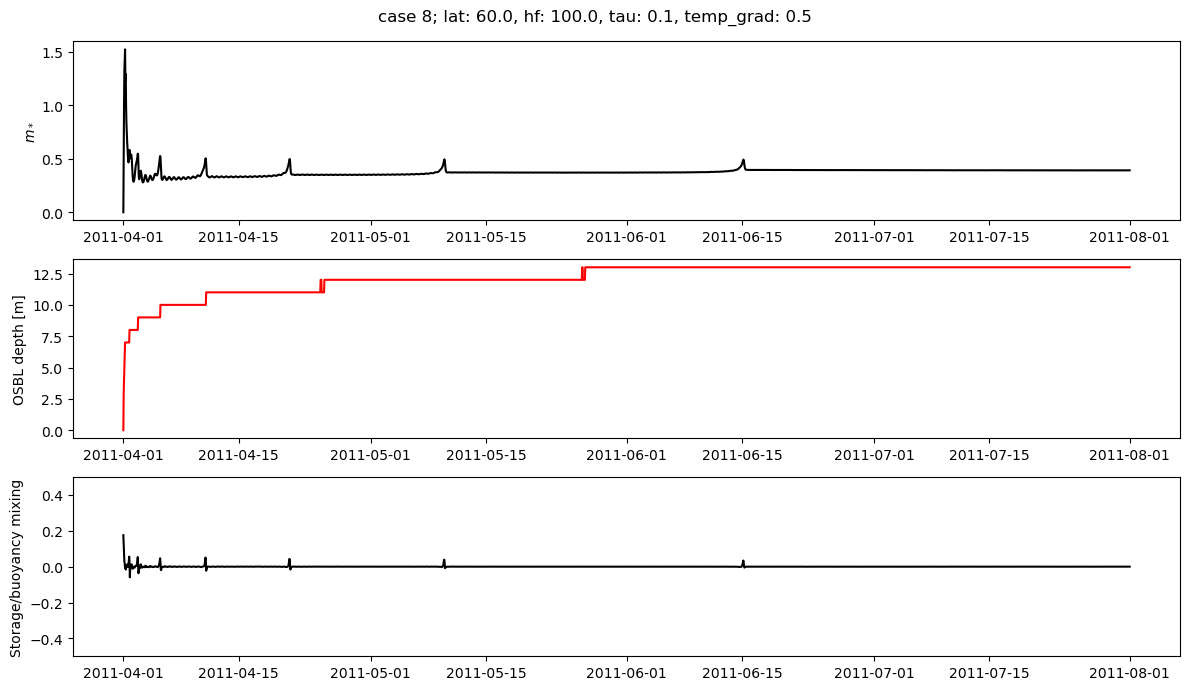

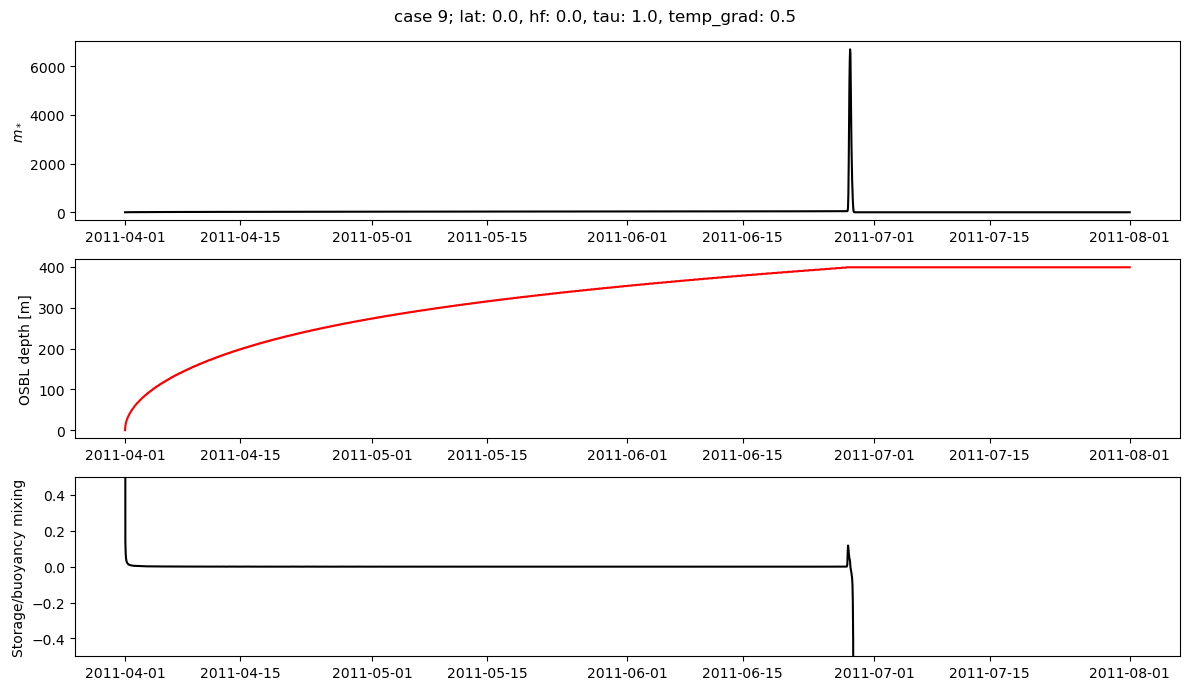

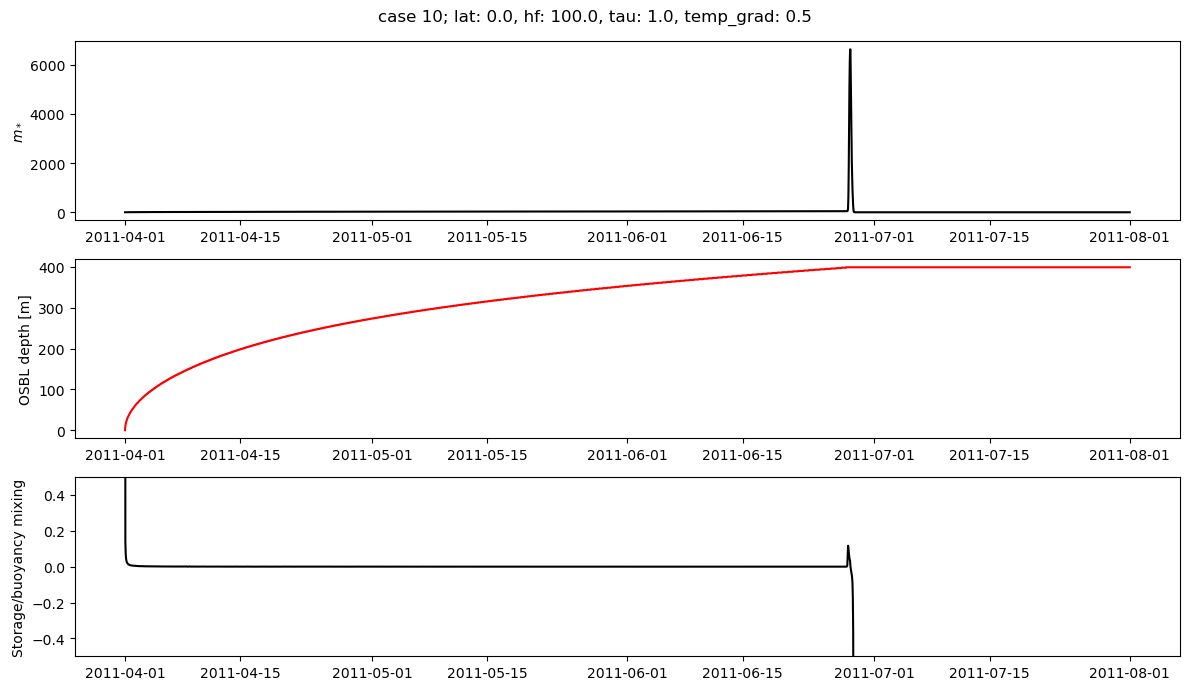

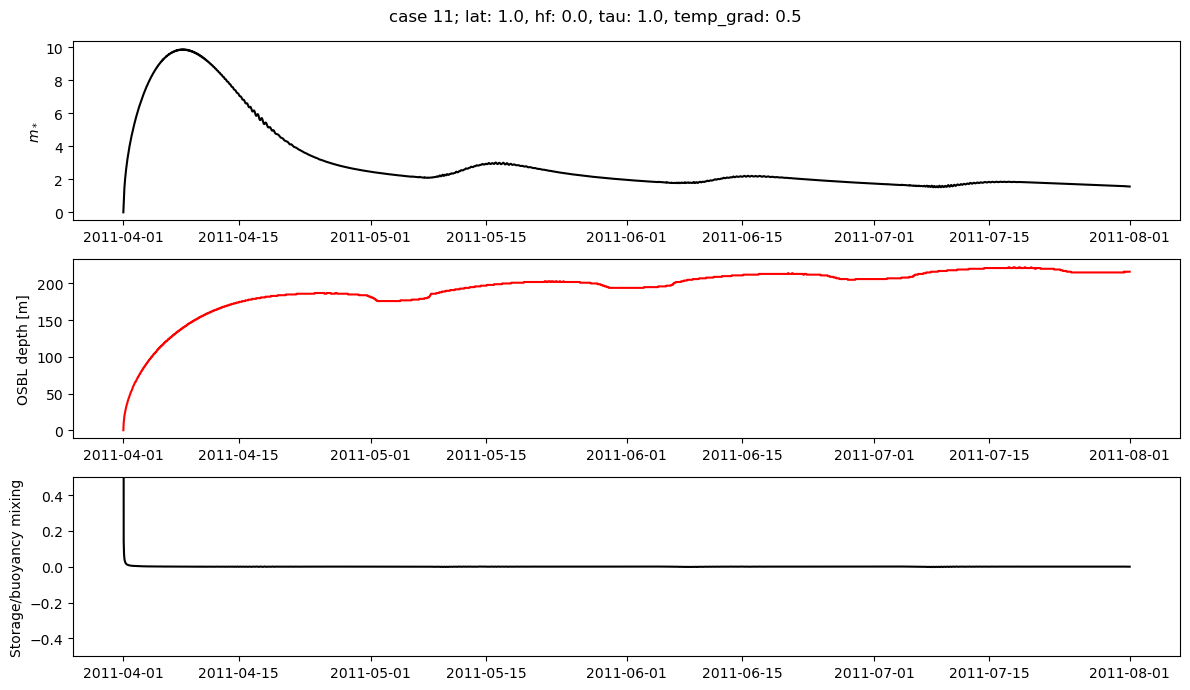

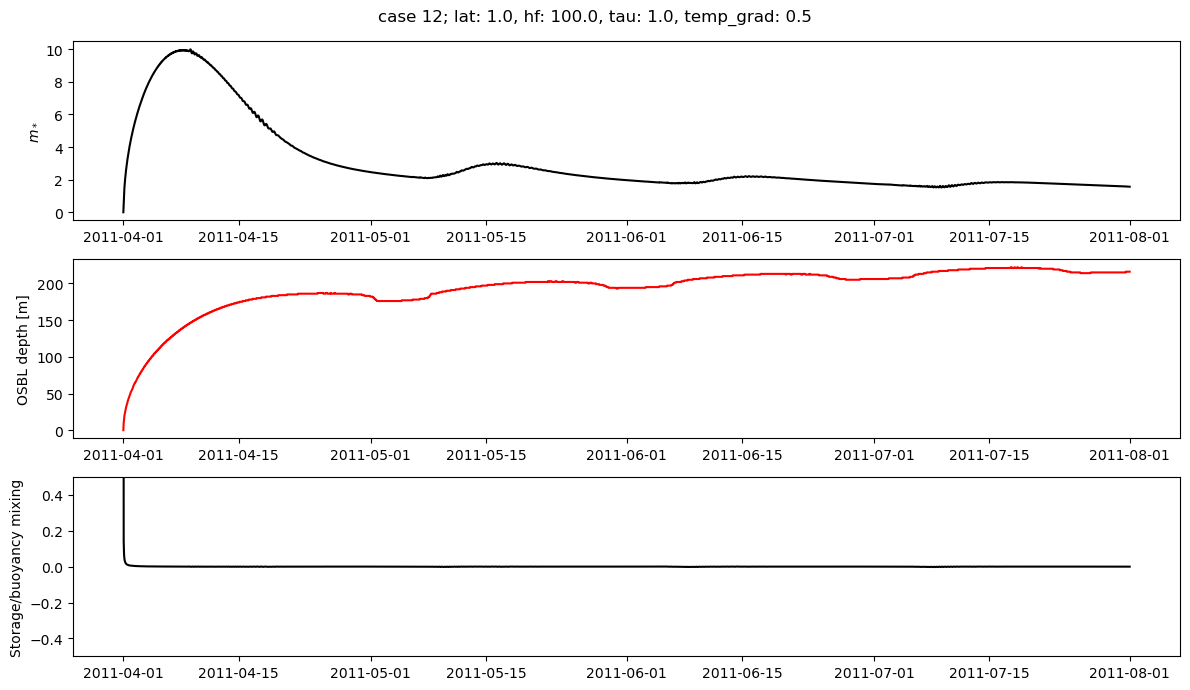

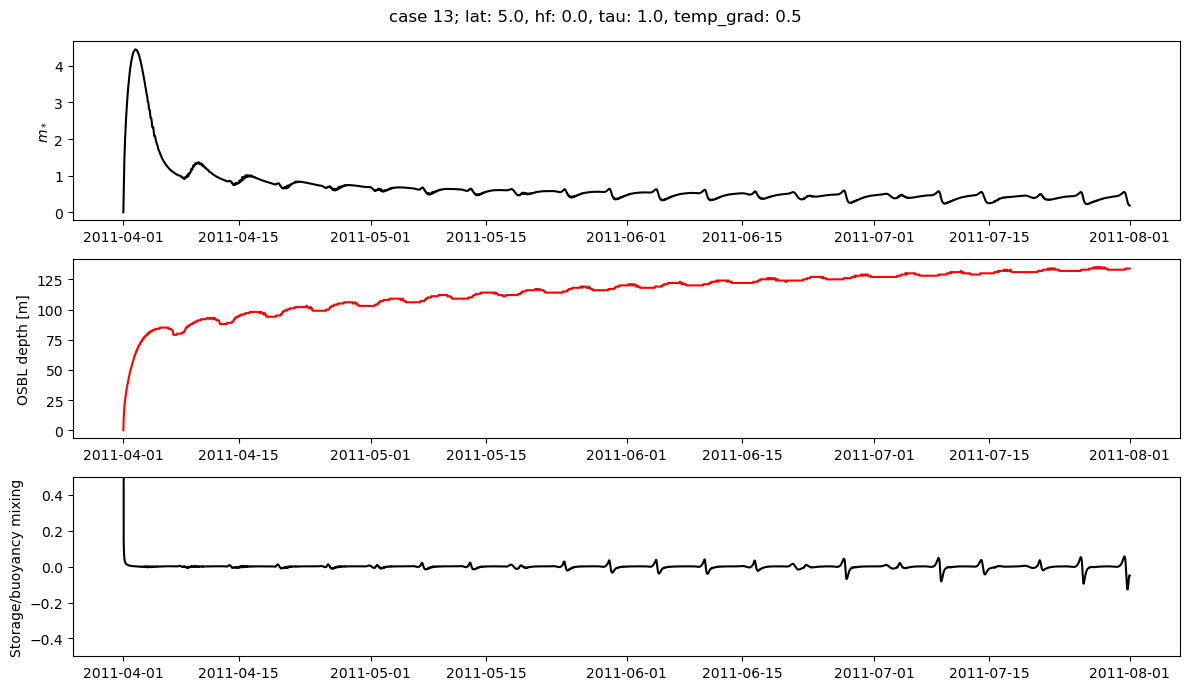

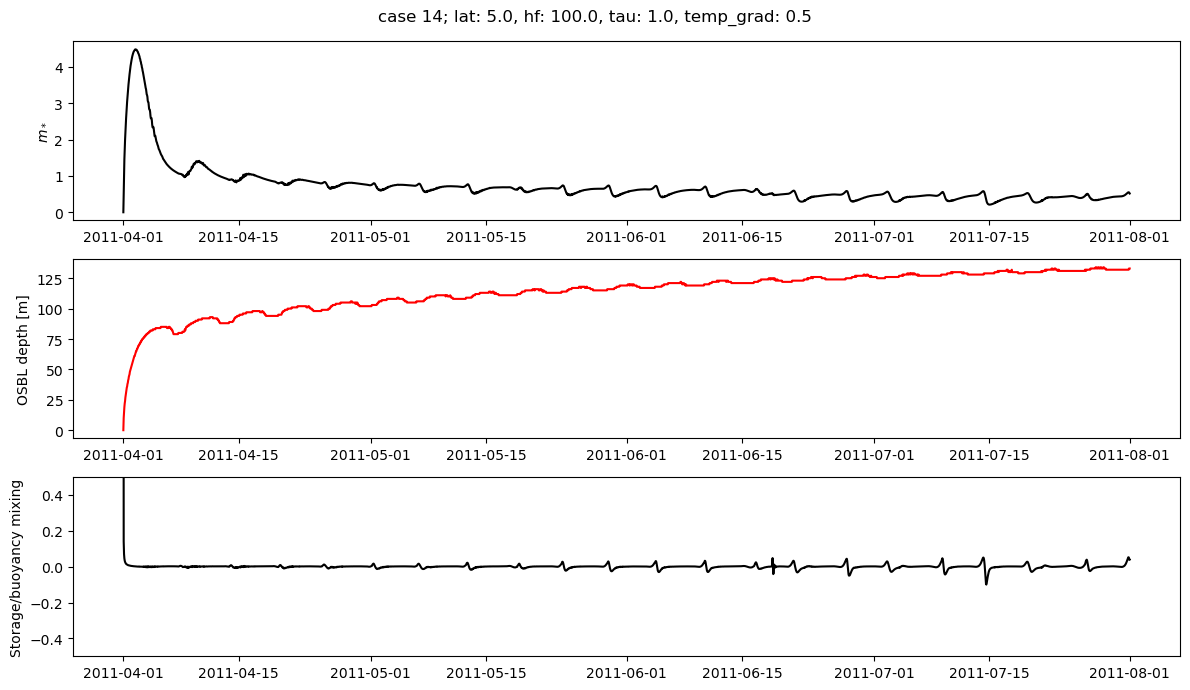

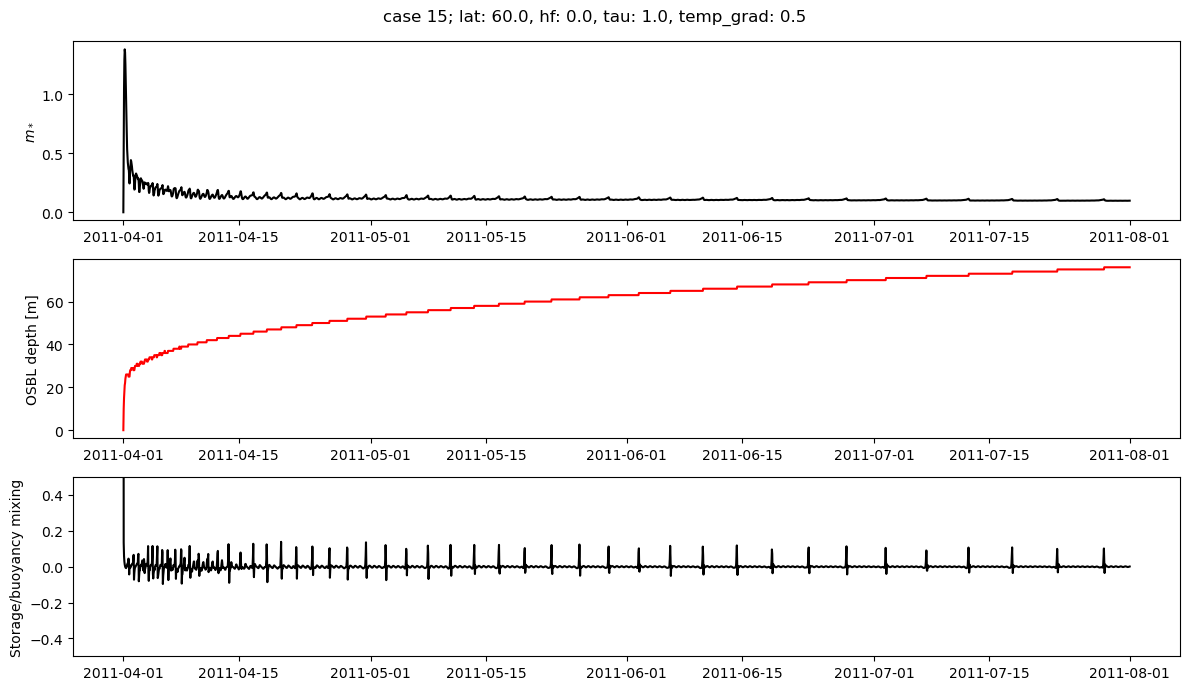

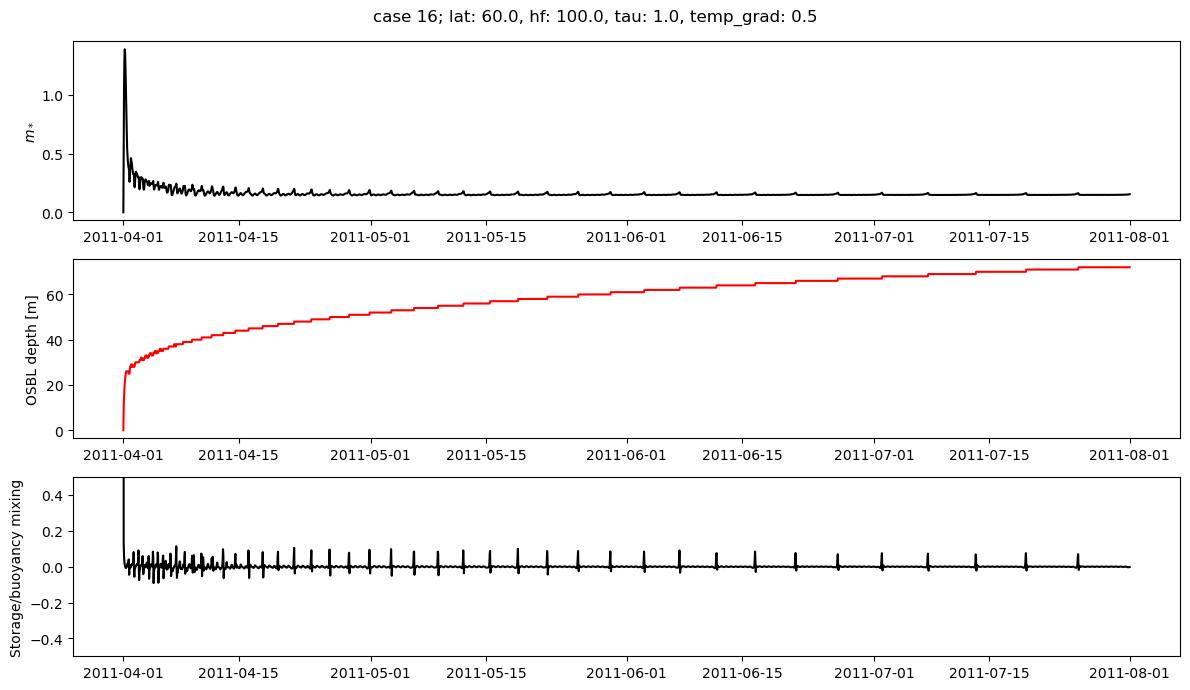

In [26]:
save = True

for i in range(0,16):
    fig, ax = plt.subplots(3,1,figsize=(12,7))
    ax[0].plot(m_star_dataset.time.values, m_star_dataset.m_star.values[i,:], color="black",
             label="$m_*$")
    ax[1].plot(bl_dataset.time.values, bl_dataset.bl.values[i,:], color="red",
             label="OSBL depth [m]")
    ax[2].plot(
        buoyancy_mixing_term_dataset.time.values, 
        storage_term_dataset.storage_term.values[i,:] / buoyancy_mixing_term_dataset.buoyancy_mixing_term.values[i,:], 
        color="black", label="Storage/buoyancy mixing")
    ax[2].set_ylim(-.5,.5)
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    fig.suptitle(f"case {i+1}; lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    ax[0].set_ylabel('$m_*$')
    ax[1].set_ylabel("OSBL depth [m]")
    ax[2].set_ylabel("Storage/buoyancy mixing")
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

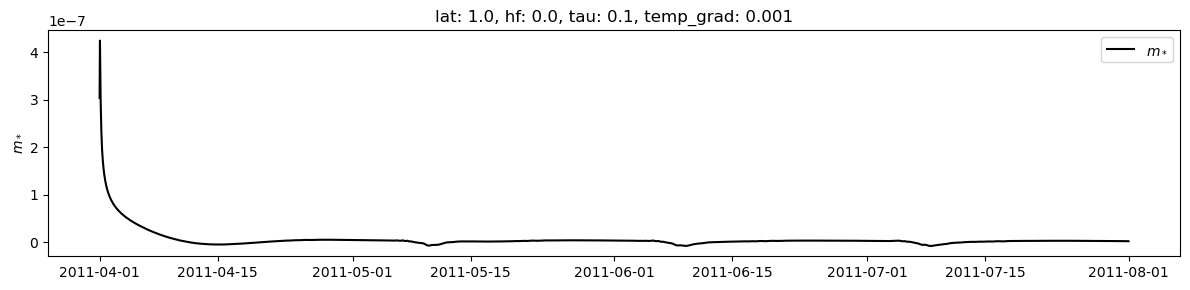

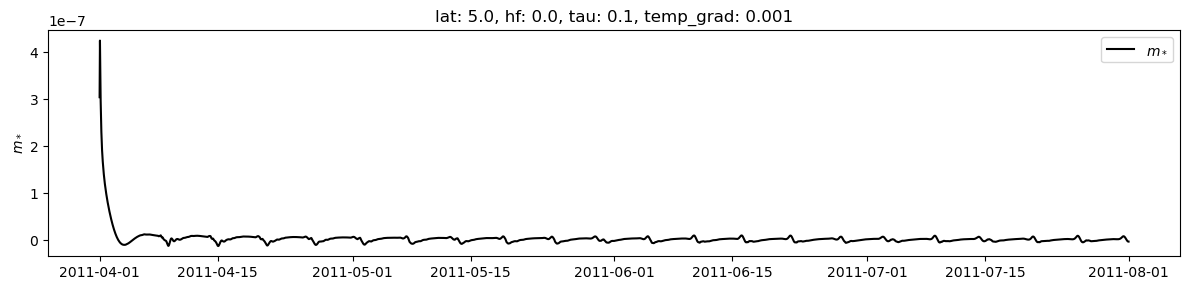

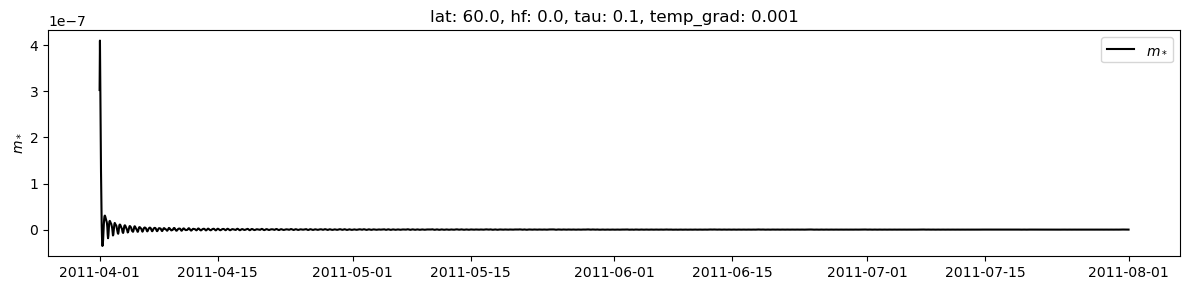

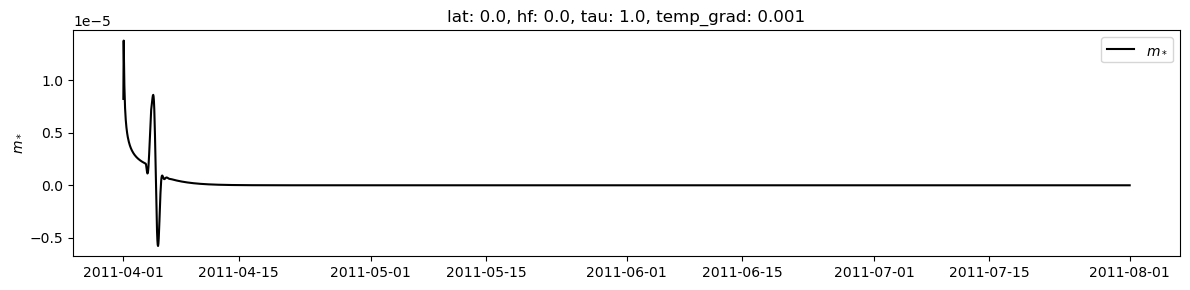

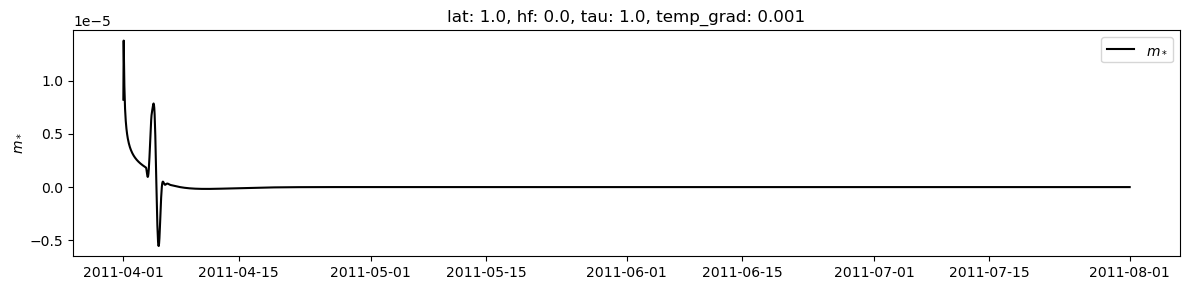

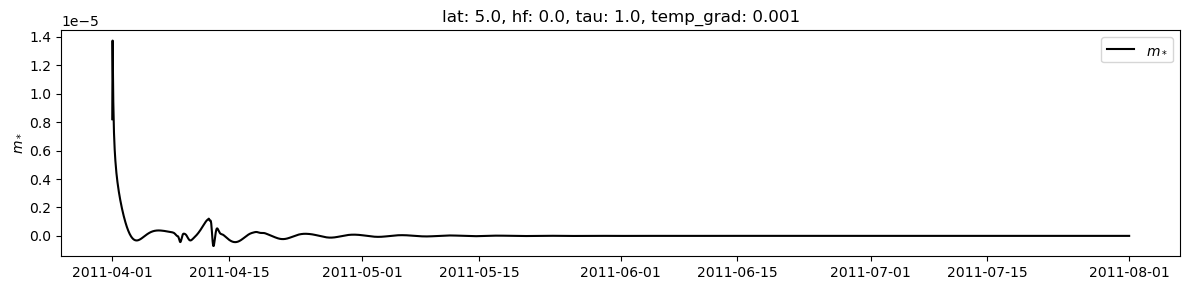

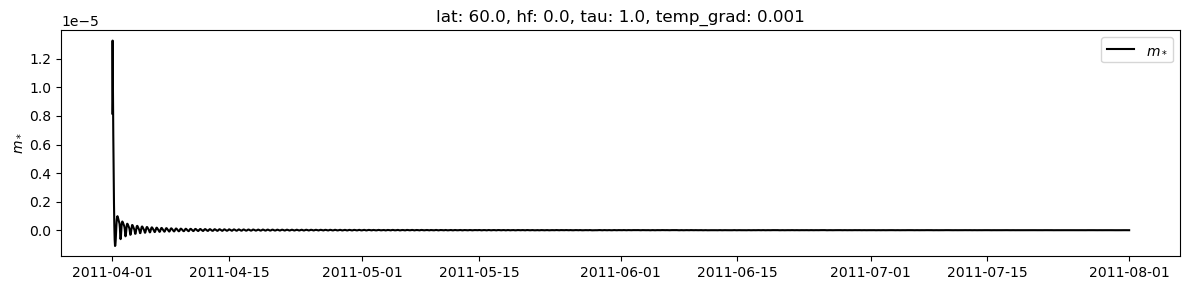

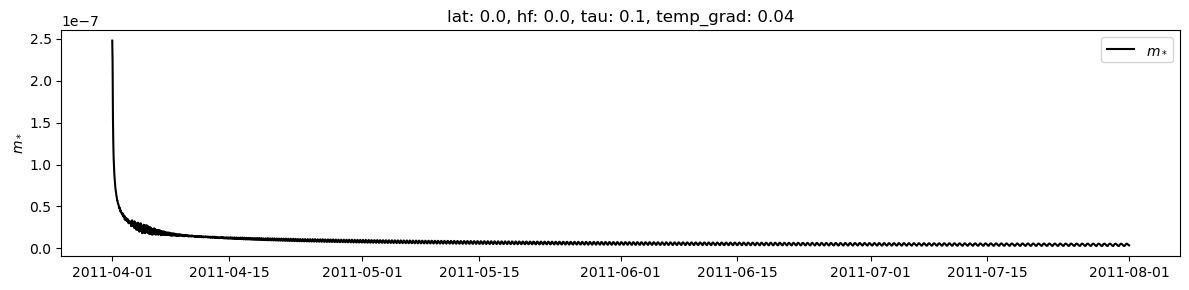

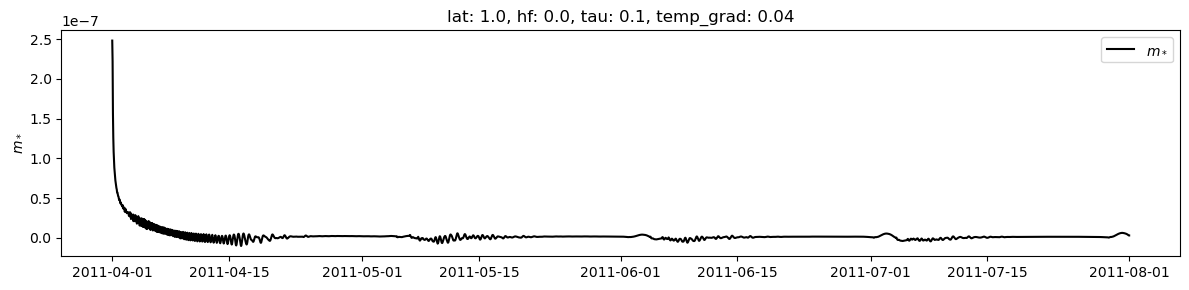

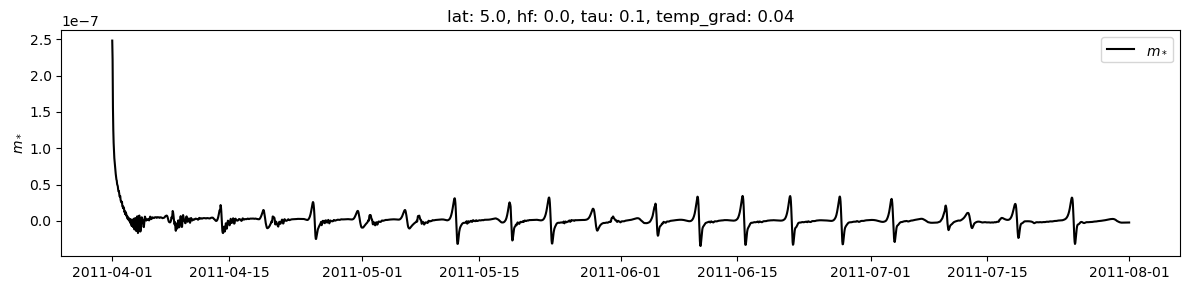

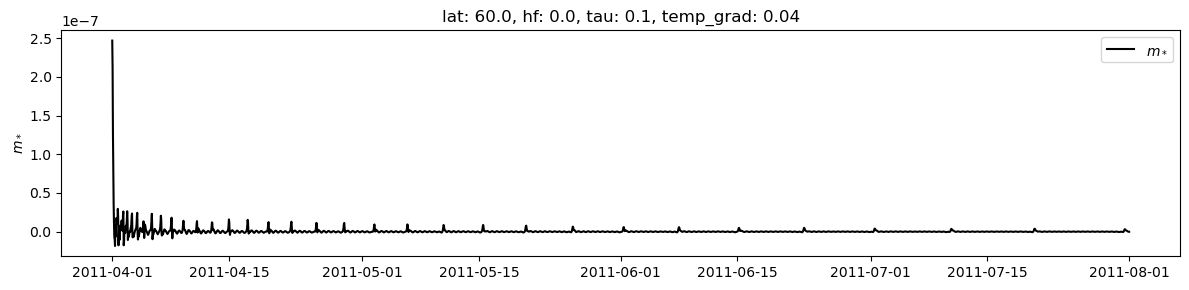

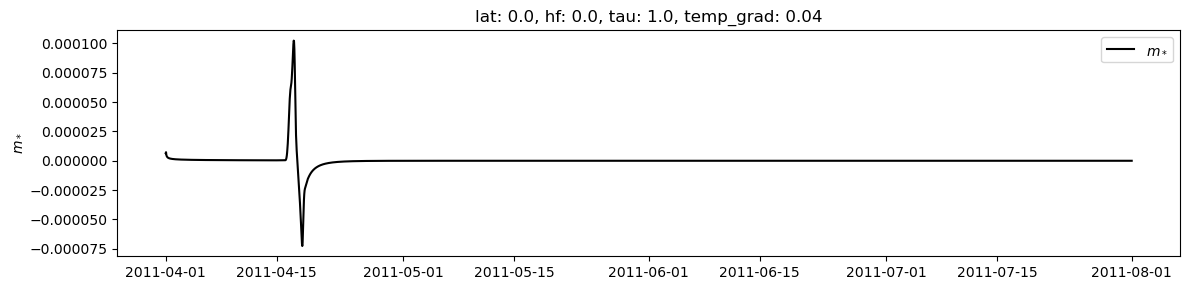

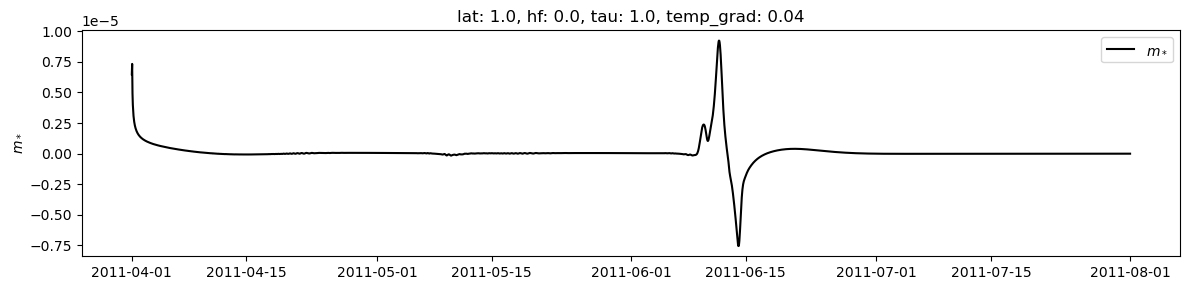

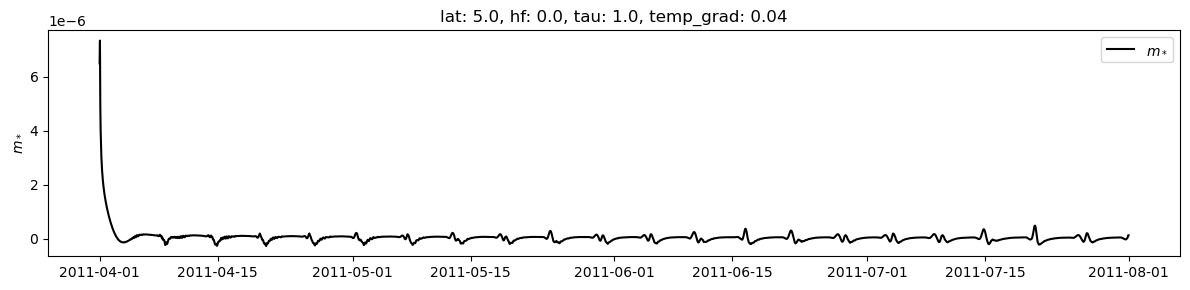

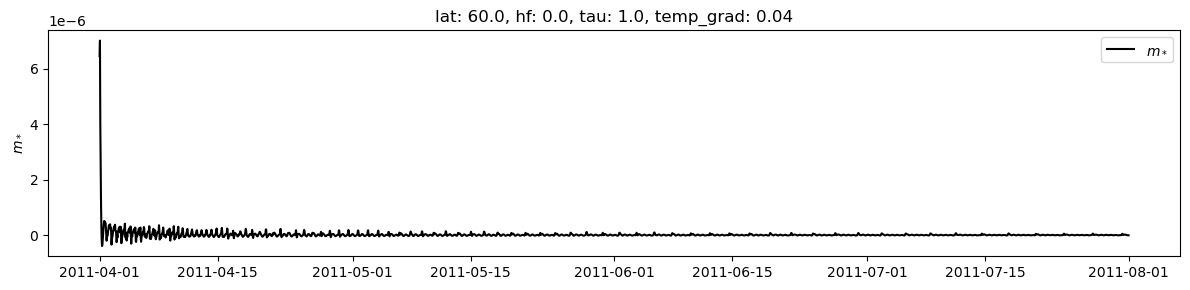

In [23]:
save = False

for i in range(1,16):
    plt.figure(figsize=(12,3))
    plt.plot(storage_term_dataset.time.values, storage_term_dataset.storage_term.values[i,:], color="black",
             label="$m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

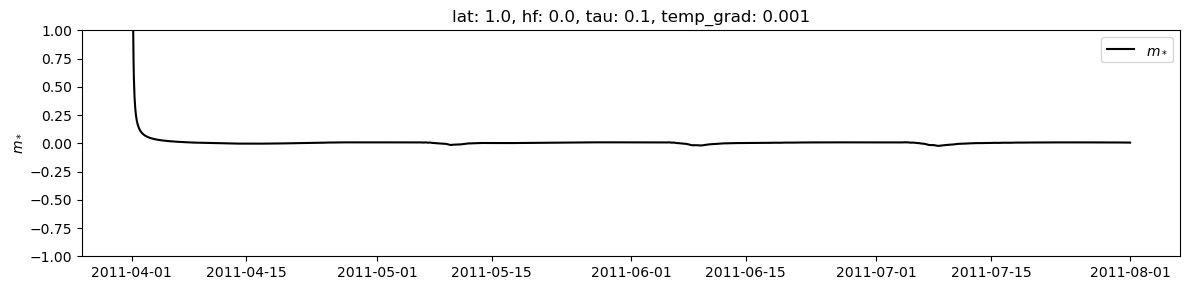

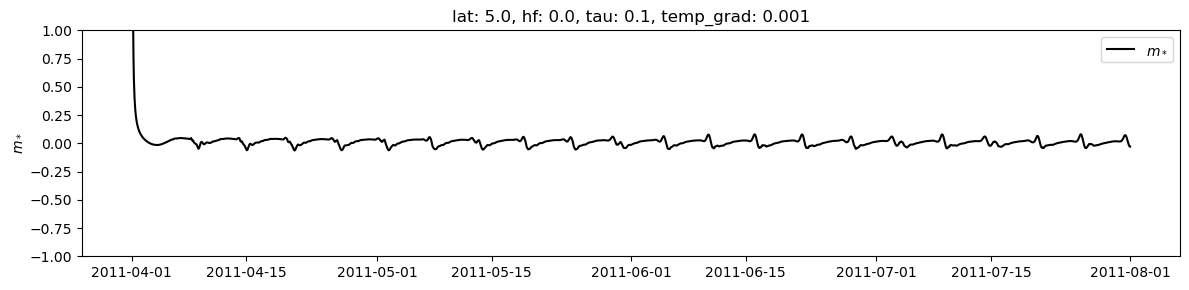

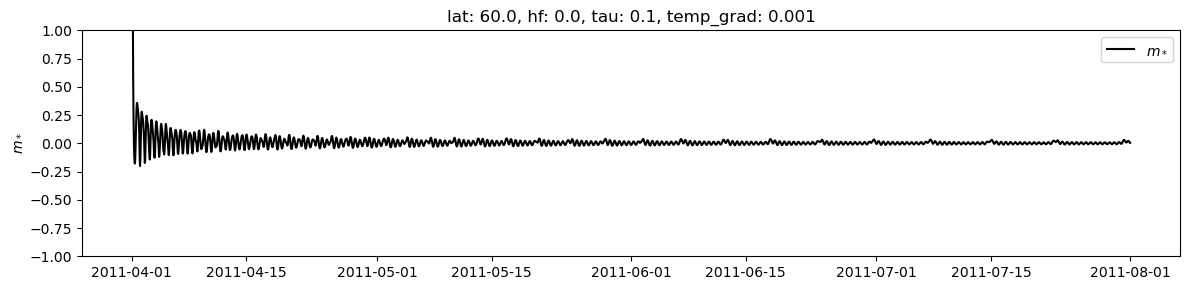

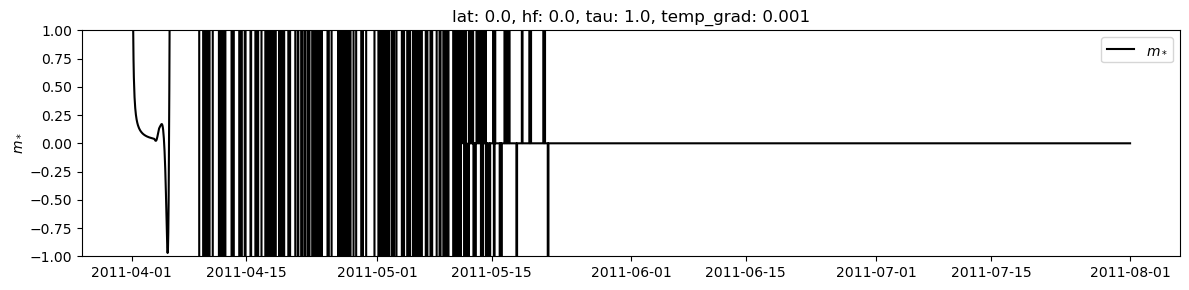

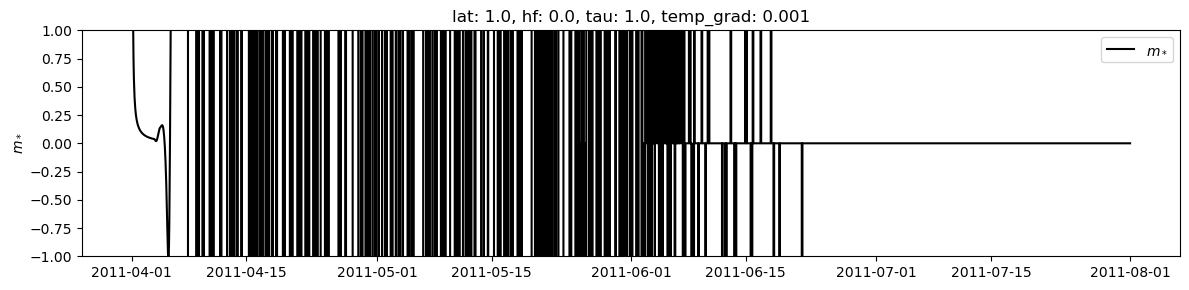

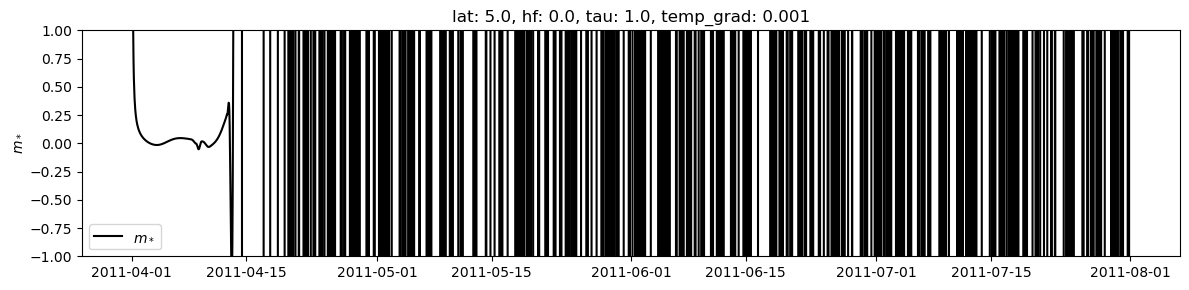

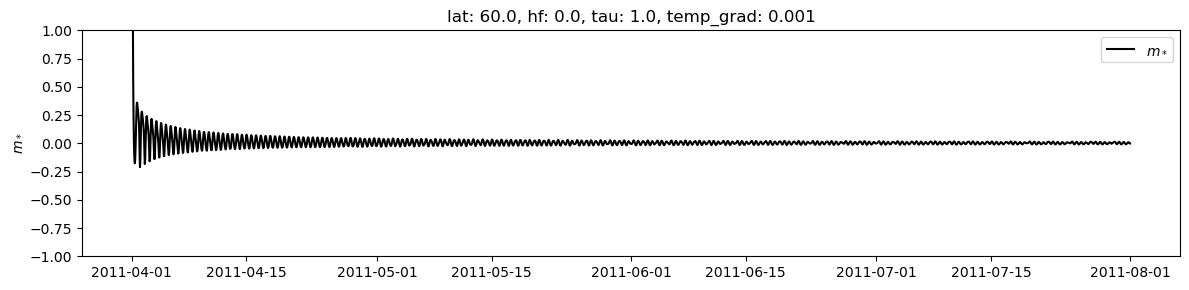

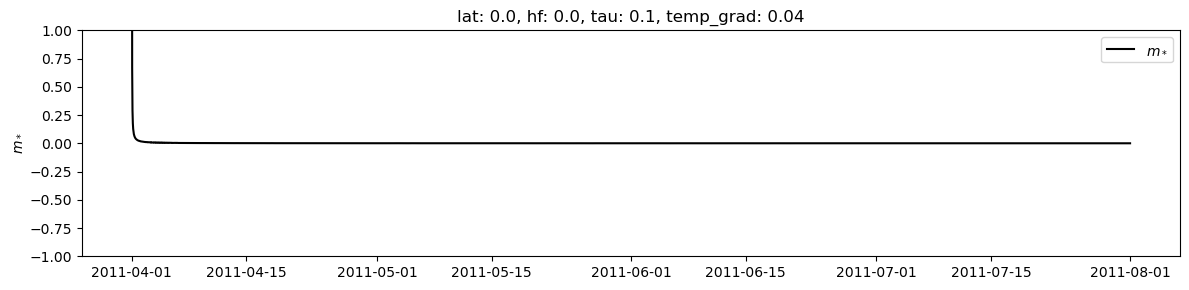

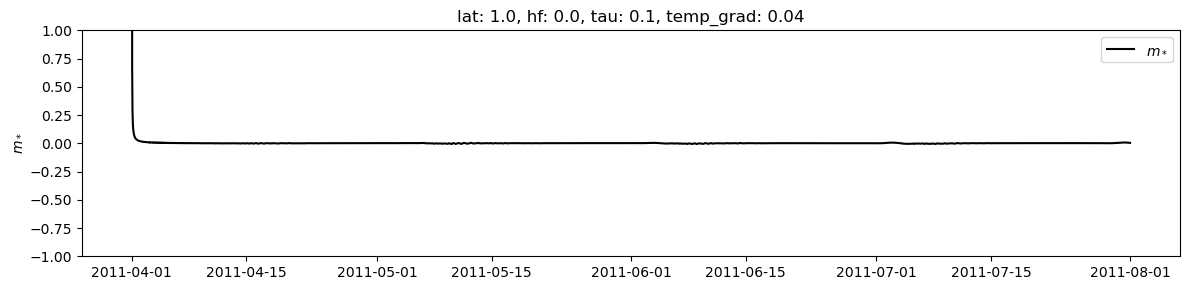

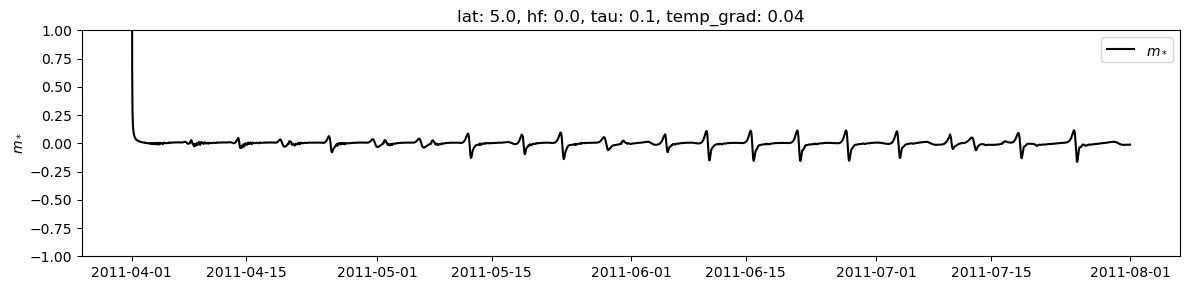

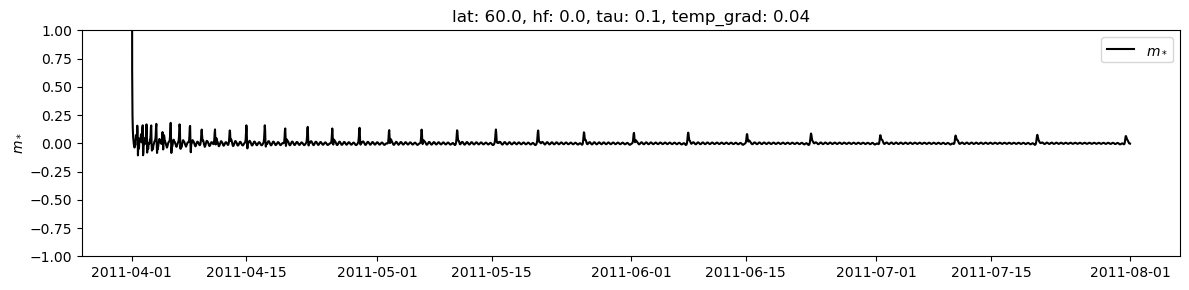

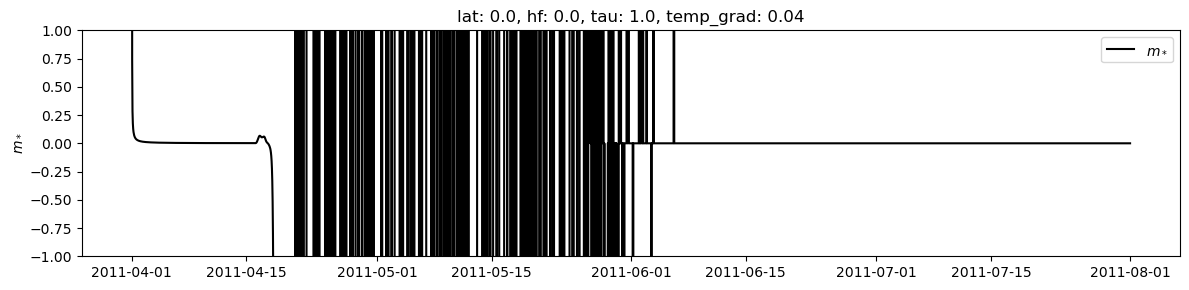

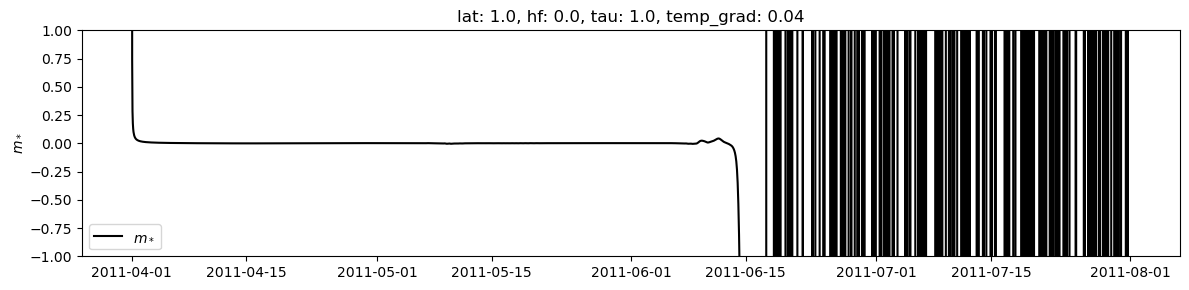

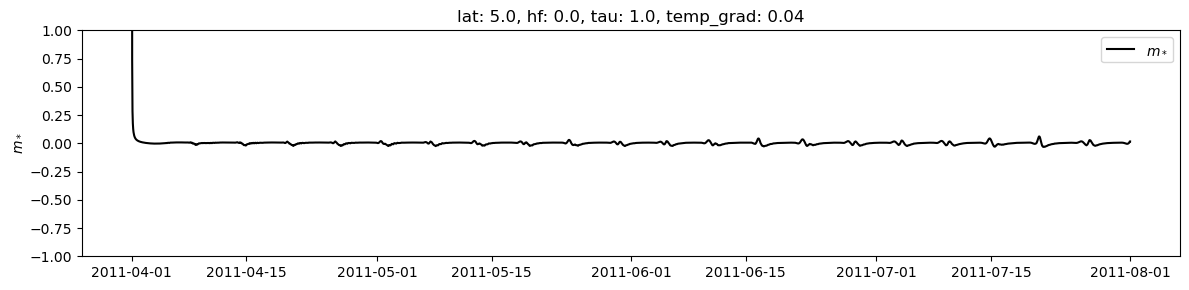

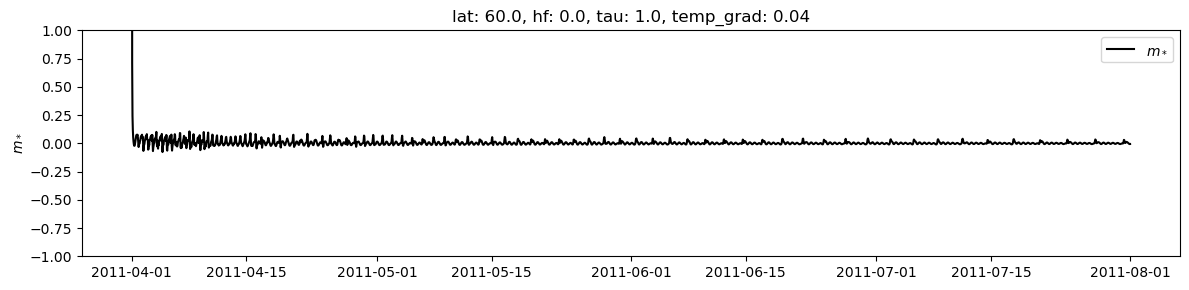

In [30]:
save = False

for i in range(1,16):
    plt.figure(figsize=(12,3))
    plt.plot(
        buoyancy_mixing_term_dataset.time.values, 
        storage_term_dataset.storage_term.values[i,:] / buoyancy_mixing_term_dataset.buoyancy_mixing_term.values[i,:], 
        color="black", label="$m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylim(-1,1)
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)